# Visualisering av vistelsetid på akutmottagningen med PROC BOX

## Sammanfattning

En analys av sjukhusdrift som använder PROC BOXPLOT (med aliaset PROC BOX) för att jämföra vistelsetiden på akutmottagningen mellan tre kliniska verksamheter. Schematiska lådagram sida vid sida visar med en blick varje verksamhets median, kvartiler, medelvärde och avvikande långa vistelser.

Över 100 simulerade besök stiger medianvistelsetiden stadigt från **40.0 timmar i Medicine** till **50.4 timmar i Surgery** till **60.5 timmar i Trauma**, och medelvärdena följer samma ordning (41.6, 54.6, 62.8 timmar). Surgery har tre höga avvikare ovanför sitt övre morrhår (upp till 84.3 timmar) — de inläggningsfall (boarding) som förbrukar flest sängtimmar. Notebooken visar jämförelsen på tre sätt: ett schematiskt diagram, ett överlägg med medelvärdestrend och en horisontell layout.

## Datakällor

All data genereras inline av det första DATA-steget (`call streaminit(20260531)`); ingen extern indata eller nätverksindata används.

**`ed_los`** — en rad per akutmottagningsbesök (100 rader)

| Variabel | Typ | Beskrivning |
|----------|------|-------------|
| `PatientID` | Num | Löpande besöksidentifierare (1-100) |
| `Department` | Char(12) | Inläggande verksamhet: Medicine, Surgery, Trauma |
| `Severity` | Char(8) | Triageakuitet: Routine (~55%), Urgent (~30%), Critical (~15%) |
| `LOS_Hours` | Num | Vistelsetid i timmar; ett medelvärde styrt av verksamhet och allvarlighetsgrad plus normalt brus, med en och annan chock av lång vistelse (märkt "Length of Stay (hours)") |

Den faktiska fördelningen är Medicine 34 / Surgery 36 / Trauma 30 besök, och Routine 51 / Urgent 35 / Critical 14 efter triageakuitet.

# Visualisering av vistelsetid på akutmottagningen med PROC BOX

Vistelsetid (LOS) är ett av de mest noggrant bevakade driftmåtten på en akutmottagning: den styr sängtillgång, bemanning, patientgenomströmning och kvalitetspoäng. Enbart medelvärden döljer historien — det som betyder något för ett driftteam är vistelsernas *spridning*, de *avvikare* som binder upp resurser och hur fördelningarna skiljer sig mellan kliniska verksamheter.

PROC BOX (ett alias för PROC BOXPLOT) är skräddarsytt för just denna jämförelse. Det ritar lådagram (box-and-whisker) sida vid sida och markerar varje grupps median, kvartiler, medelvärde och extrema observationer, så att en analytiker med en blick kan avläsa formen på varje verksamhets LOS-fördelning.

I den här notebooken:

1. Genererar vi en syntetisk datamängd med akutmottagningsbesök som passar 100-observationersmiljön.
2. Skapar vi ett schematiskt lådagram över LOS per verksamhet, med tillhörande statistiktabell.
3. Lägger vi över en medelvärdestrendlinje med `BOXCONNECT=MEAN` för att göra verksamhetsgradienten tydlig.
4. Ritar vi om samma jämförelse horisontellt med `HORIZONTAL`.

## Steg 1 — Generera syntetisk data för akutmottagningsbesök

Vi simulerar 100 akutmottagningsbesök. Varje patient tilldelas en av tre kliniska verksamheter (Medicine, Surgery, Trauma) och en triage-allvarlighetsgrad (Routine, Urgent, Critical). Vistelsetiden byggs upp från en verksamhetsspecifik baslinje, förskjuten uppåt för patienter med högre akuitet, med normalfördelat brus. En liten andel besök får en extra chock av lång vistelse för att efterlikna den tunga högersvans som verklig akutmottagningsdata alltid uppvisar (boarding, inläggningar som väntar på en vårdplats). Det fasta fröet i `call streaminit` gör datamängden fullt reproducerbar.

In [1]:
ALTERNATIV linesize=96;

data ed_los;
   CALL streaminit(20260531);
   LÄNGD Department $ 12 Severity $ 12;
   GÖR PatientID = 1 TILL 100;
      d = rand('integer', 1, 3);
      OM d = 1 SÅ Department = "Medicin";
      ANNARS OM d = 2 SÅ Department = "Kirurgi";
      ANNARS Department = "Trauma";

      u = rand('uniform');
      OM u < 0.55 SÅ s = 1;
      ANNARS OM u < 0.85 SÅ s = 2;
      ANNARS s = 3;
      OM s = 1 SÅ Severity = "Rutin";
      ANNARS OM s = 2 SÅ Severity = "Brådskande";
      ANNARS Severity = "Kritisk";

      BASE = 24 + 10*d + 14*(s - 1);
      LOS_Hours = BASE + rand('normal', 0, 7);
      OM rand('uniform') < 0.06 SÅ
         LOS_Hours = LOS_Hours + rand('uniform', 40, 90);
      OM LOS_Hours < 2 SÅ LOS_Hours = 2;
      LOS_Hours = round(LOS_Hours, 0.1);
      UTDATA;
   SLUT;
   TA_BORT d u s BASE;
   ETIKETT LOS_Hours = "Vårdtid (timmar)"
         Department = "Avdelning"
         Severity   = "Allvarlighetsgrad";
KÖR;


NOTE: Option LINESIZE changed to 96.
NOTE: DATA ed_los


NOTE: Wrote ed_los (100 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


## Steg 2 — Sortera efter grupperingsvariabeln

PROC BOX förväntar sig att grupperingsvariabeln (horisontalaxeln) är sorterad så att observationerna för varje grupp ligger i följd. Vi sorterar efter `Department` före plottningen.

In [2]:
PROCEDUR SORTERA data=ed_los;
   EFTER Department;
KÖR;


NOTE: PROC SORT data=ed_los

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from ed_los.
NOTE: Wrote ed_los (100 rows, 4 columns).
NOTE: PROC SORT statement used.


## Steg 3 — Schematiskt lådagram

Kärnan i analysen. Syntaxen `PLOT analysis-var * group-var` begär en låda per verksamhet. `BOXSTYLE=SCHEMATIC` ger ett klassiskt schematiskt Tukey-diagram: morrhåren sträcker sig till de mest extrema observationerna inom 1.5 gånger interkvartilavståndet, och alla punkter utanför det ritas individuellt som avvikare — idealiskt för att upptäcka de långa vistelser som belastar kapaciteten.

`NOHLABEL` undertrycker den överflödiga etiketten på horisontalaxeln eftersom verksamhetsnamnen är självförklarande. Vid sidan av diagrammet skriver PROC BOXPLOT ut en statistiktabell med varje verksamhets N, minimum, kvartiler, median, maximum, medelvärde och standardavvikelse.

                           Vårdtid på akutmottagningen per avdelning                            

                          Vårdtid på akutmottagningen per avdelning

                                     The BOXPLOT Procedure

Schematic Plots for Vårdtid (timmar)

Avdelning             N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
Kirurgi              36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
Medicin              34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
Trauma               30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
------------------------------------------------------------------------------------------------------------



NOTE: Option TITLE changed to Vårdtid på akutmottagningen per avdelning.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


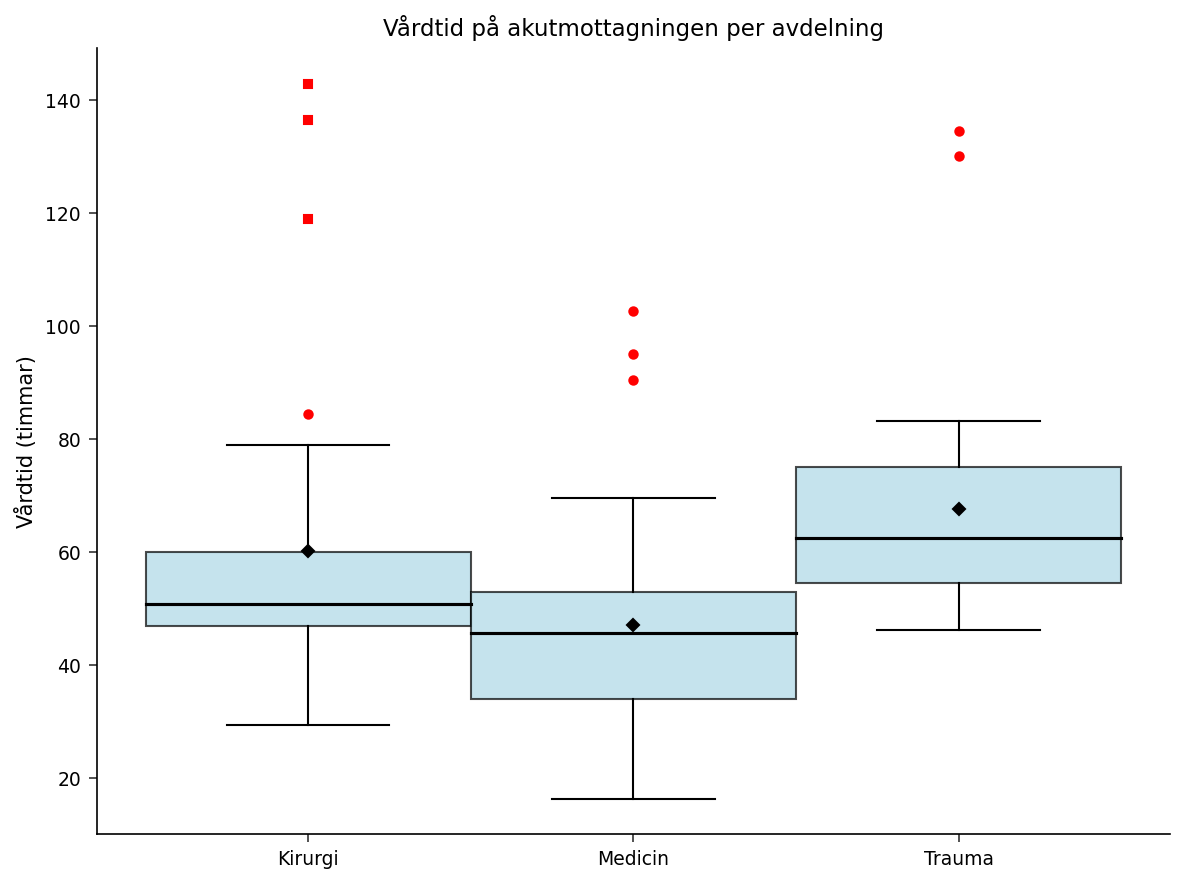

In [3]:
TITEL "Vårdtid på akutmottagningen per avdelning";
PROCEDUR boxplot data=ed_los;
   PLOT LOS_Hours*Department /
      boxstyle = schematic
      nohlabel;
KÖR;

## Steg 4 — Lägg över en medelvärdestrendlinje

För att göra gradienten mellan verksamheterna tydlig lägger vi till `BOXCONNECT=MEAN`. PROC BOXPLOT ritar då en förbindelselinje genom medelvärdet för varje låda (diamantmarkörerna), vilket förvandlar de tre separata fördelningarna till en enda lättläst trend. Eftersom verksamheterna ordnas Medicine → Surgery → Trauma sammanfattar den stigande förbindelselinjen upptrappningen i genomsnittlig vistelsetid i ett enda drag — en användbar ledtråd för en driftdashboard.

                     Vårdtid på akutmottagningen per avdelning - medeltrend                     

                    Vårdtid på akutmottagningen per avdelning - medeltrend

                                     The BOXPLOT Procedure

Schematic Plots for Vårdtid (timmar)

Avdelning             N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
Kirurgi              36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
Medicin              34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
Trauma               30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
------------------------------------------------------------------------------------------------------------



NOTE: Option TITLE changed to Vårdtid på akutmottagningen per avdelning - medeltrend.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


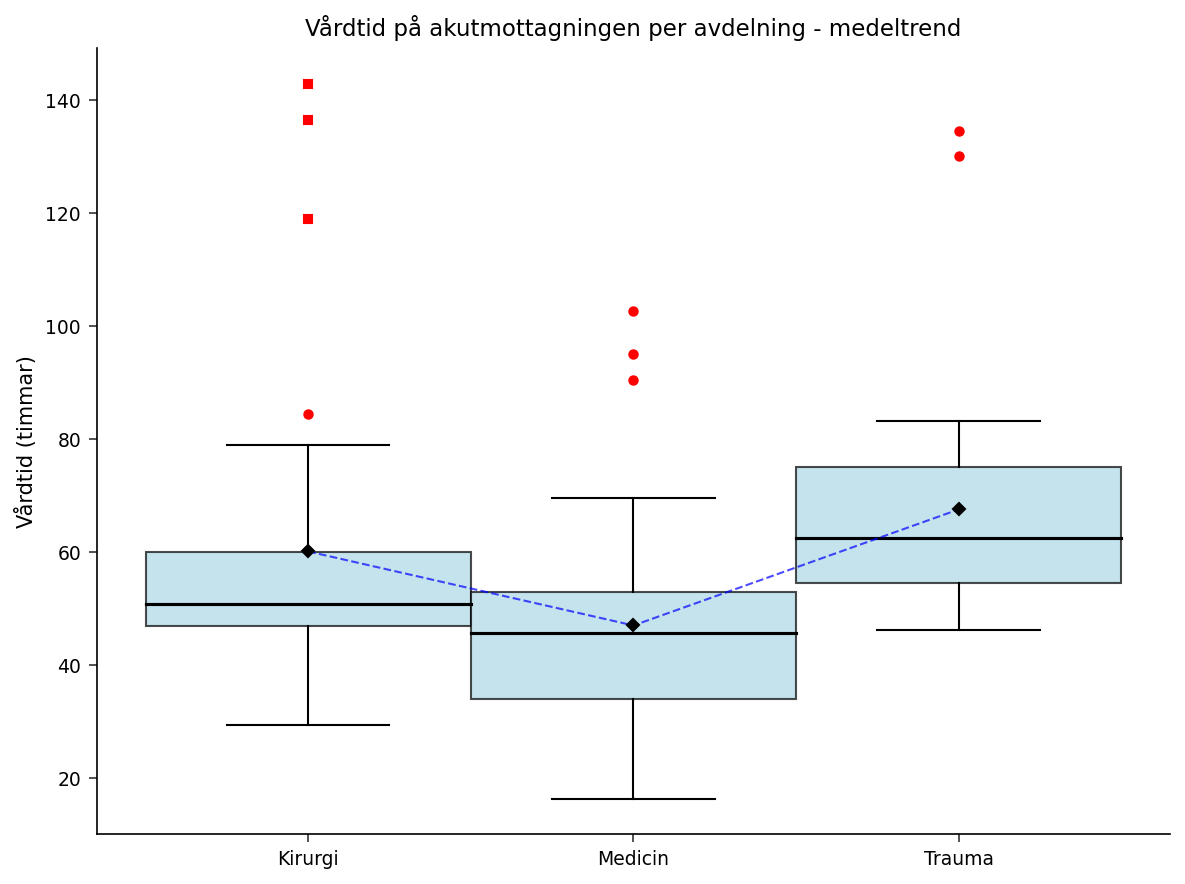

In [4]:
TITEL "Vårdtid på akutmottagningen per avdelning - medeltrend";
PROCEDUR boxplot data=ed_los;
   PLOT LOS_Hours*Department /
      boxstyle    = schematic
      boxconnect  = mean
      nohlabel;
KÖR;

## Steg 5 — Horisontell layout

Samma jämförelse läses naturligt på sidan. Att lägga till `HORIZONTAL` byter axlar så att lådorna löper från vänster till höger med responsen på x-axeln — en layout som skalar bättre när verksamhetsnamnen är långa eller många, och som många driftdashboards föredrar. Statistiken är identisk med den vertikala vyn; endast orienteringen ändras.

                    Vårdtid på akutmottagningen per avdelning - horisontell                     

                   Vårdtid på akutmottagningen per avdelning - horisontell

                                     The BOXPLOT Procedure

Schematic Plots for Vårdtid (timmar)

Avdelning             N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
Kirurgi              36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
Medicin              34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
Trauma               30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
------------------------------------------------------------------------------------------------------------



NOTE: Option TITLE changed to Vårdtid på akutmottagningen per avdelning - horisontell.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


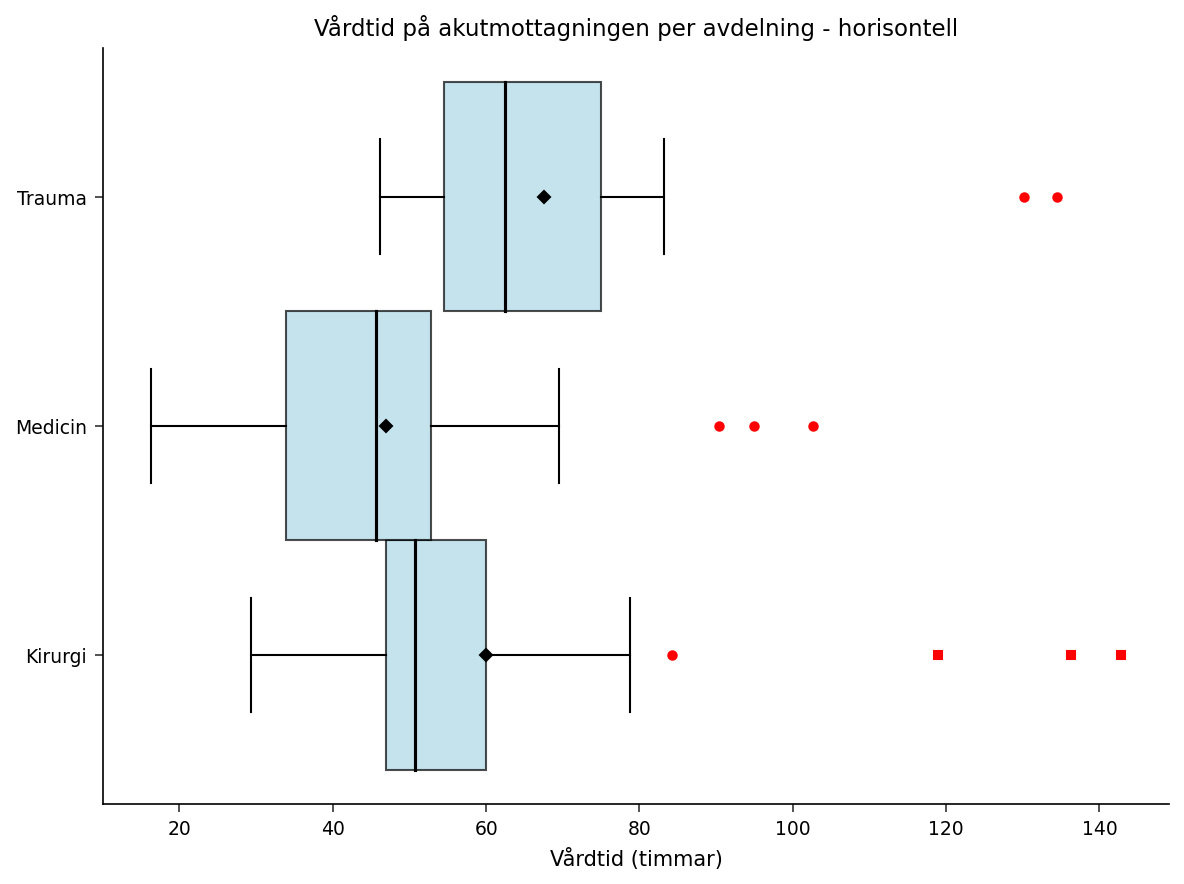

In [5]:
TITEL "Vårdtid på akutmottagningen per avdelning - horisontell";
PROCEDUR boxplot data=ed_los;
   PLOT LOS_Hours*Department /
      boxstyle   = schematic
      horizontal
      nohlabel;
KÖR;

## Tolkning av resultaten

Lådagrammen och den tillhörande statistiktabellen omsätter rådata om LOS till en operativt handlingsbar bild:

- **En tydlig verksamhetsgradient.** Medianvistelsetiden stiger monotont över de tre verksamheterna: **Medicine 40.0 h → Surgery 50.4 h → Trauma 60.5 h**. Medelvärdena berättar samma historia (41.6, 54.6, 62.8 h), och `BOXCONNECT=MEAN`-linjen i Steg 4 ritar den upptrappningen som en enda stigande trend. Trauma-patienter stannar i genomsnitt ungefär 50 % längre än Medicine-patienter.

- **Variabiliteten spelar lika stor roll som medianen.** Interkvartilavståndet (lådans höjd) är störst för Medicine (Q1 32.8 h till Q3 51.2 h, en spridning på 18.3 timmar) och minst för Trauma (Q1 54.5 h till Q3 68.5 h, en spridning på 14.0 timmar). Medicine är därför inte bara den kortaste verksamheten utan också den minst förutsägbara — den egenskap som försvårar prognoser för sängplatshantering.

- **Avvikarna pekar ut inläggningsfallen (boarding).** De schematiska morrhåren stannar vid 1.5 × IQR, så de tre röda punkterna ovanför Surgerys övre morrhår (med topp vid 84.3 h) framträder som genuina långa vistelser — precis de inläggningsfall som förbrukar oproportionerligt många sängtimmar. Medicine och Trauma visar inga punkter utanför sina morrhår i detta urval.

- **Spännvidden berättar historien om kapacitetsplanering.** Observerade vistelser spänner över 16.3–69.5 h i Medicine, 29.3–84.3 h i Surgery och 46.1–83.2 h i Trauma. Trauma ger aldrig en kort vistelse (dess minimum, 46.1 h, överstiger Medicines median), vilket är vad ett driftteam skulle förvänta sig av den mest resurskrävande verksamheten.

Tillsammans ger dessa vyer en ledningsgrupp på akutmottagningen en försvarbar, fördelningsmedveten grund för bemanning och kapacitetsplanering — långt mer informativ än att enbart jämföra genomsnittlig LOS per verksamhet.